#processing_service

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


Upload dataset

In [2]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    dataset_path = filename

print("Uploaded file:", dataset_path)

Saving customer_spending_1M_2018_2025.csv to customer_spending_1M_2018_2025.csv
Uploaded file: customer_spending_1M_2018_2025.csv


In [3]:
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (1000000, 11)


,Transaction_ID,Transaction_date,Gender,Age,Marital_status,State_names,Segment,Employees_status,Payment_method,Referral,Amount_spent
0,1000,2018-01-01T00:04:00.000000,Female,39.0,Single,Oklahoma,Platinum,Unemployment,Card,0.0,1557.50
1,1001,2018-01-01T00:06:00.000000,Male,34.0,Married,Hawaii,Basic,workers,PayPal,1.0,153.55
2,1002,2018-01-01T00:14:00.000000,Female,53.0,Married,Iowa,Basic,self-employed,PayPal,1.0,2640.96
3,1003,2018-01-01T00:23:00.000000,Male,33.0,Married,Wisconsin,Basic,self-employed,Card,1.0,293.58
4,1004,2018-01-01T00:25:00.000000,Female,36.0,Married,Texas,Platinum,Employees,Card,0.0,1608.01


Explore dataset

In [4]:
print("Columns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()

Columns:
Index(['Transaction_ID', 'Transaction_date', 'Gender', 'Age', 'Marital_status',
       'State_names', 'Segment', 'Employees_status', 'Payment_method',
       'Referral', 'Amount_spent'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Transaction_ID    1000000 non-null  int64  
 1   Transaction_date  1000000 non-null  object 
 2   Gender            988948 non-null   object 
 3   Age               983346 non-null   float64
 4   Marital_status    1000000 non-null  object 
 5   State_names       1000000 non-null  object 
 6   Segment           1000000 non-null  object 
 7   Employees_status  989775 non-null   object 
 8   Payment_method    1000000 non-null  object 
 9   Referral          938188 non-null   float64
 10  Amount_spent      903935 non-null   float64
dtypes: float64(3)

,Transaction_ID,Age,Referral,Amount_spent
count,1.000000e+06,983346.000000,938188.000000,903935.000000
mean,5.009995e+05,46.647170,0.652339,1416.126106
std,2.886753e+05,18.183986,0.476228,878.123082
min,1.000000e+03,15.000000,0.000000,2.090000
25%,2.509998e+05,32.000000,0.000000,677.360000
50%,5.009995e+05,47.000000,1.000000,1332.480000
75%,7.509992e+05,62.000000,1.000000,2037.590000
max,1.000999e+06,78.000000,1.000000,2999.980000


Clean column names

In [5]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

print(df.columns)

Index(['Transaction_ID', 'Transaction_date', 'Gender', 'Age', 'Marital_status',
       'State_names', 'Segment', 'Employees_status', 'Payment_method',
       'Referral', 'Amount_spent'],
      dtype='object')


Convert date column

In [6]:
df["Transaction_date"] = pd.to_datetime(df["Transaction_date"], errors="coerce")

df["Year"] = df["Transaction_date"].dt.year
df["Month"] = df["Transaction_date"].dt.month
df["Quarter"] = df["Transaction_date"].dt.quarter
df["Day"] = df["Transaction_date"].dt.day
df["Hour"] = df["Transaction_date"].dt.hour
df["Month_Year"] = df["Transaction_date"].dt.to_period("M").astype(str)

df.head()

,Transaction_ID,Transaction_date,Gender,Age,Marital_status,State_names,Segment,Employees_status,Payment_method,Referral,Amount_spent,Year,Month,Quarter,Day,Hour,Month_Year
0,1000,2018-01-01 00:04:00,Female,39.0,Single,Oklahoma,Platinum,Unemployment,Card,0.0,1557.50,2018,1,1,1,0,2018-01
1,1001,2018-01-01 00:06:00,Male,34.0,Married,Hawaii,Basic,workers,PayPal,1.0,153.55,2018,1,1,1,0,2018-01
2,1002,2018-01-01 00:14:00,Female,53.0,Married,Iowa,Basic,self-employed,PayPal,1.0,2640.96,2018,1,1,1,0,2018-01
3,1003,2018-01-01 00:23:00,Male,33.0,Married,Wisconsin,Basic,self-employed,Card,1.0,293.58,2018,1,1,1,0,2018-01
4,1004,2018-01-01 00:25:00,Female,36.0,Married,Texas,Platinum,Employees,Card,0.0,1608.01,2018,1,1,1,0,2018-01


Basic data cleaning

In [7]:
df = df.drop_duplicates()

df = df.dropna(subset=["Transaction_ID", "Transaction_date", "Amount_spent"])

df["Amount_spent"] = pd.to_numeric(df["Amount_spent"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

df = df.dropna(subset=["Amount_spent", "Age"])

df["Gender"] = df["Gender"].astype(str).str.strip()
df["Marital_status"] = df["Marital_status"].astype(str).str.strip()
df["State_names"] = df["State_names"].astype(str).str.strip()
df["Segment"] = df["Segment"].astype(str).str.strip()
df["Employees_status"] = df["Employees_status"].astype(str).str.strip()
df["Payment_method"] = df["Payment_method"].astype(str).str.strip()

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (888388, 17)


,Transaction_ID,Transaction_date,Gender,Age,Marital_status,State_names,Segment,Employees_status,Payment_method,Referral,Amount_spent,Year,Month,Quarter,Day,Hour,Month_Year
0,1000,2018-01-01 00:04:00,Female,39.0,Single,Oklahoma,Platinum,Unemployment,Card,0.0,1557.50,2018,1,1,1,0,2018-01
1,1001,2018-01-01 00:06:00,Male,34.0,Married,Hawaii,Basic,workers,PayPal,1.0,153.55,2018,1,1,1,0,2018-01
2,1002,2018-01-01 00:14:00,Female,53.0,Married,Iowa,Basic,self-employed,PayPal,1.0,2640.96,2018,1,1,1,0,2018-01
3,1003,2018-01-01 00:23:00,Male,33.0,Married,Wisconsin,Basic,self-employed,Card,1.0,293.58,2018,1,1,1,0,2018-01
4,1004,2018-01-01 00:25:00,Female,36.0,Married,Texas,Platinum,Employees,Card,0.0,1608.01,2018,1,1,1,0,2018-01


Save raw and cleaned data

In [8]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/output", exist_ok=True)
os.makedirs("models", exist_ok=True)

df.to_csv("data/processed/cleaned_transactions.csv", index=False)

print("Cleaned data saved successfully")

Cleaned data saved successfully


Monthly sales aggregation

In [9]:
monthly_sales = df.groupby("Month_Year").agg(
    total_sales=("Amount_spent", "sum"),
    average_sales=("Amount_spent", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index()

monthly_sales.to_csv("data/output/monthly_sales.csv", index=False)

monthly_sales.head()

,Month_Year,total_sales,average_sales,transaction_count
0,2018-01,15326440.63,1426.511600,10744
1,2018-02,13662317.69,1414.318601,9660
2,2018-03,15249706.43,1426.272580,10692
3,2018-04,14404211.21,1410.932629,10209
4,2018-05,15101864.43,1416.286639,10663


Quarterly sales aggregation

In [10]:
quarterly_sales = df.groupby(["Year", "Quarter"]).agg(
    total_sales=("Amount_spent", "sum"),
    average_sales=("Amount_spent", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index()

quarterly_sales.to_csv("data/output/quarterly_sales.csv", index=False)

quarterly_sales.head()

,Year,Quarter,total_sales,average_sales,transaction_count
0,2018,1,44238464.75,1422.641650,31096
1,2018,2,43964620.02,1416.294698,31042
2,2018,3,44602855.04,1418.665873,31440
3,2018,4,44447857.78,1409.700532,31530
4,2019,1,44050997.81,1422.789891,30961


Segment-wise aggregation

In [11]:
segment_sales = df.groupby("Segment").agg(
    total_sales=("Amount_spent", "sum"),
    average_sales=("Amount_spent", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index().sort_values(by="total_sales", ascending=False)

segment_sales.to_csv("data/output/segment_sales.csv", index=False)

segment_sales

,Segment,total_sales,average_sales,transaction_count
0,Basic,5.767203e+08,1416.209725,407228
4,Silver,2.377482e+08,1410.767496,168524
3,Platinum,2.261366e+08,1460.274498,154859
1,Gold,1.186660e+08,1384.958096,85682
2,Missing,1.029923e+08,1428.563998,72095


State-wise aggregation

In [12]:
state_sales = df.groupby("State_names").agg(
    total_sales=("Amount_spent", "sum"),
    average_sales=("Amount_spent", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index().sort_values(by="total_sales", ascending=False)

state_sales.to_csv("data/output/state_sales.csv", index=False)

state_sales.head(10)

,State_names,total_sales,average_sales,transaction_count
12,Illinois,34800710.38,1457.011111,23885
20,Massachusetts,33853456.47,1510.371039,22414
24,Missouri,32965385.48,1613.419415,20432
22,Minnesota,32557712.60,1498.904866,21721
2,Arizona,31953292.23,1617.478726,19755
29,New Jersey,31707510.94,1606.419644,19738
31,New York,31032283.86,1569.347823,19774
38,Rhode Island,30496723.14,1624.326133,18775
40,South Dakota,29051912.33,1662.294005,17477
16,Kentucky,28890570.18,1462.369416,19756


In [24]:
df.to_csv("data/processed/cleaned_transactions.csv", index=False)
monthly_sales.to_csv("data/output/monthly_sales.csv", index=False)
quarterly_sales.to_csv("data/output/quarterly_sales.csv", index=False)
segment_sales.to_csv("data/output/segment_sales.csv", index=False)
state_sales.to_csv("data/output/state_sales.csv", index=False)

#visualization_service

Graph 1 — Monthly total sales

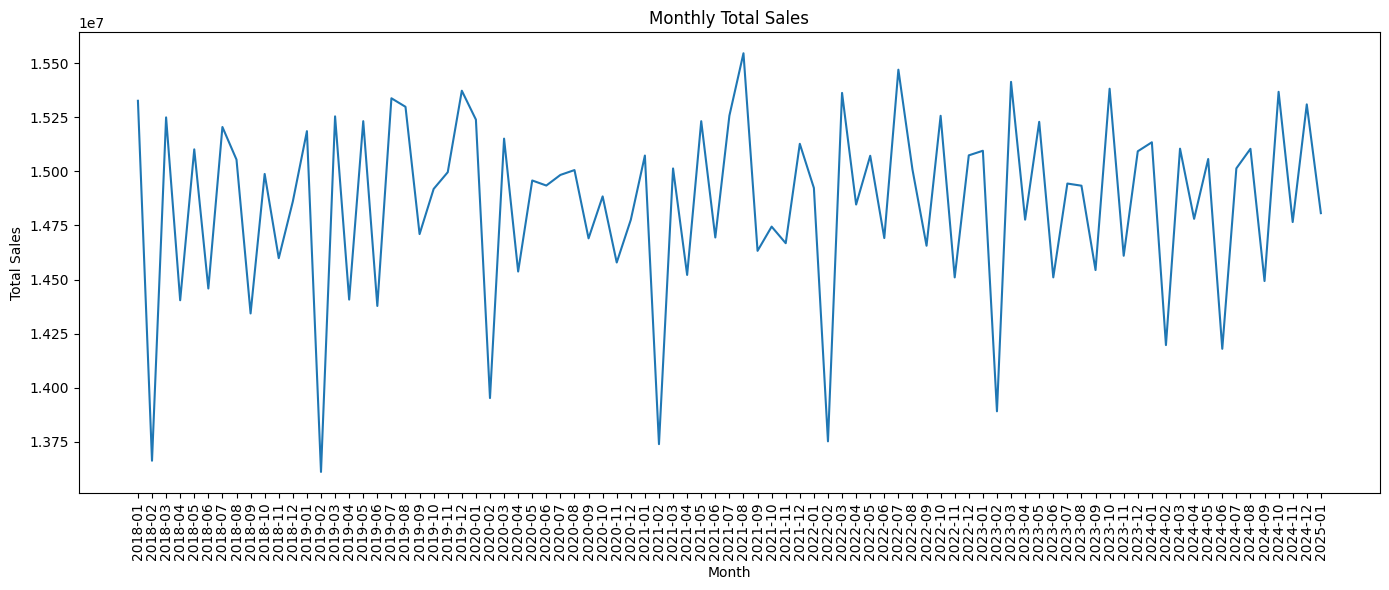

In [13]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales["Month_Year"], monthly_sales["total_sales"])
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("data/output/monthly_total_sales.png", dpi=300)
plt.show()

Graph 2 — Segment sales

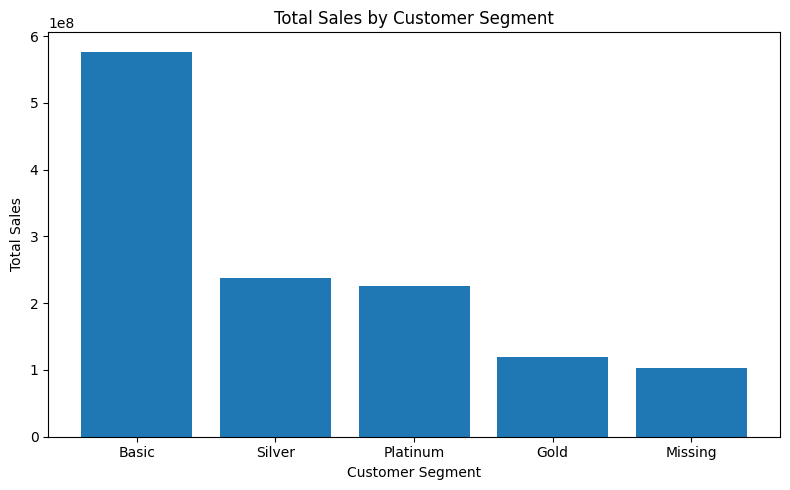

In [14]:
plt.figure(figsize=(8,5))
plt.bar(segment_sales["Segment"], segment_sales["total_sales"])
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("data/output/segment_sales.png", dpi=300)
plt.show()

Graph 3 — Payment method sales

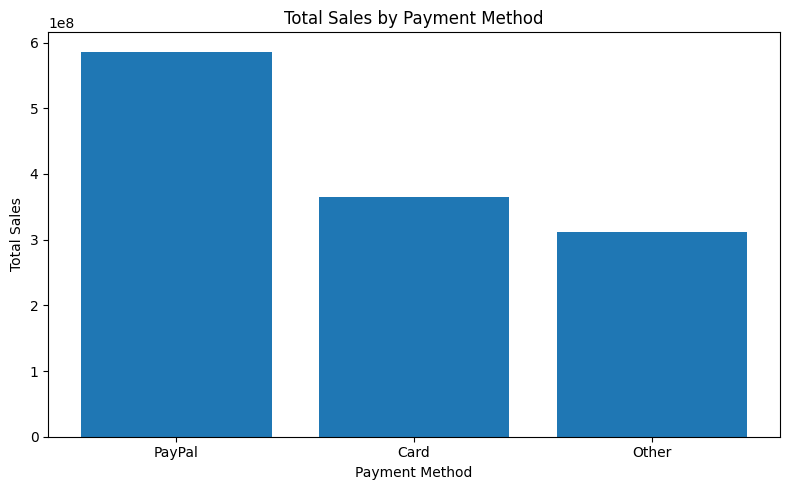

In [15]:
payment_sales = df.groupby("Payment_method").agg(
    total_sales=("Amount_spent", "sum")
).reset_index().sort_values(by="total_sales", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(payment_sales["Payment_method"], payment_sales["total_sales"])
plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("data/output/payment_method_sales.png", dpi=300)
plt.show()

Graph 4 — Top 10 states by sales

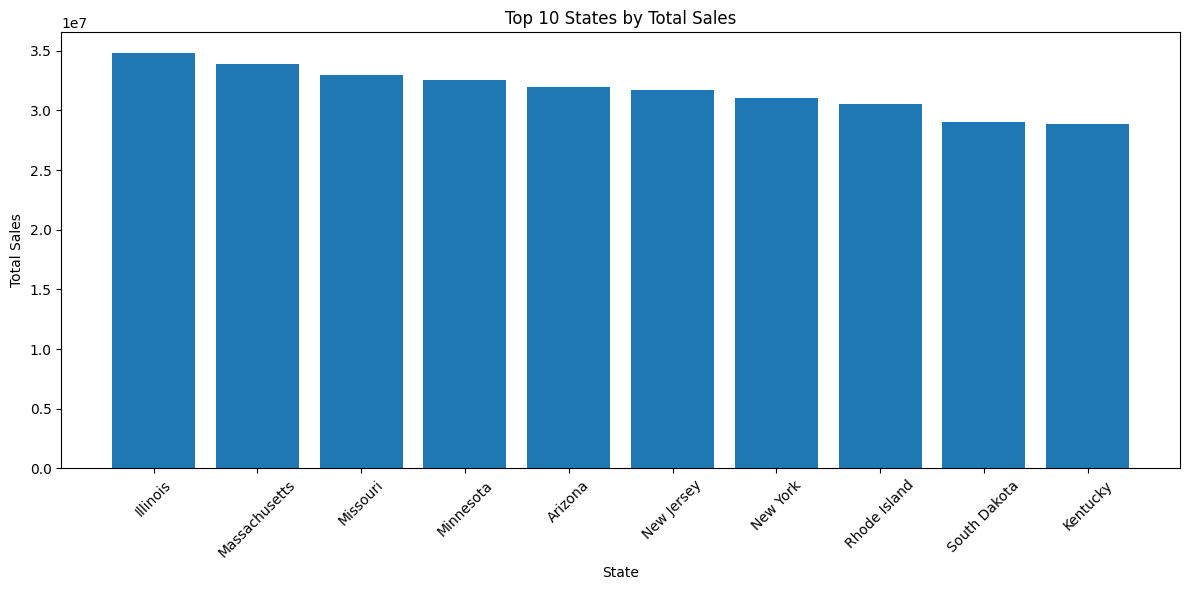

In [16]:
top_states = state_sales.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_states["State_names"], top_states["total_sales"])
plt.title("Top 10 States by Total Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/output/top_10_states_sales.png", dpi=300)
plt.show()

Monthly Average Sales

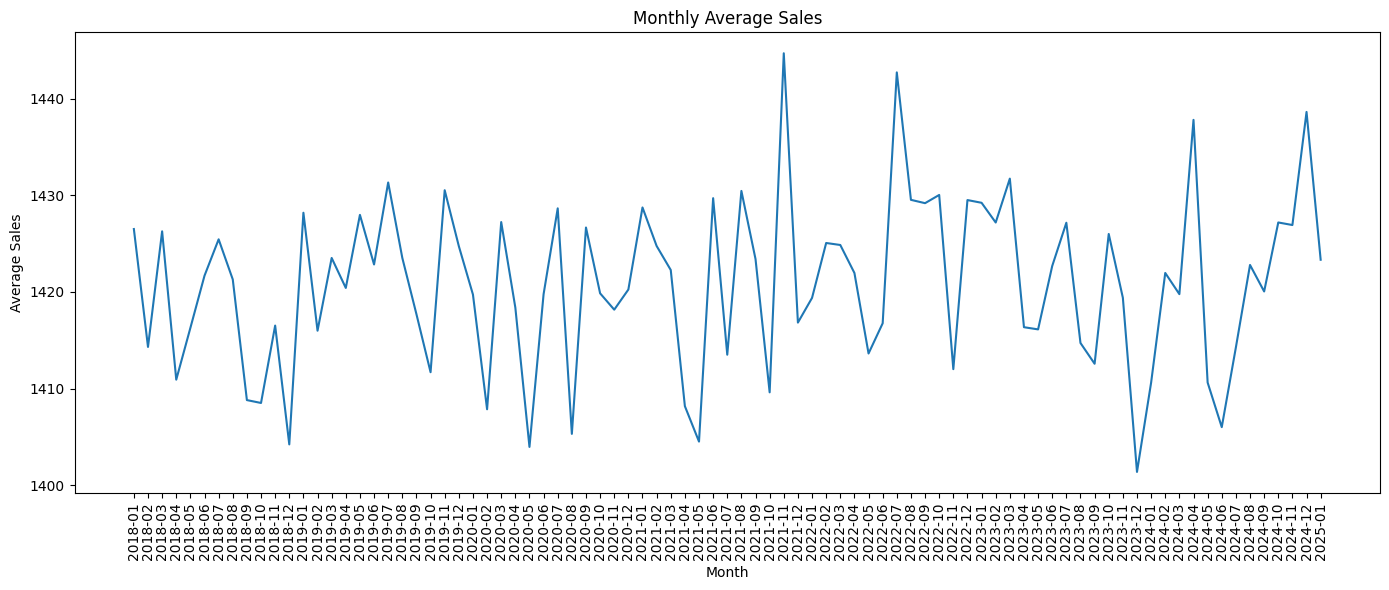

In [17]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales["Month_Year"], monthly_sales["average_sales"])
plt.title("Monthly Average Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("data/output/monthly_avg_sales.png", dpi=300)
plt.show()

Monthly Transaction Count

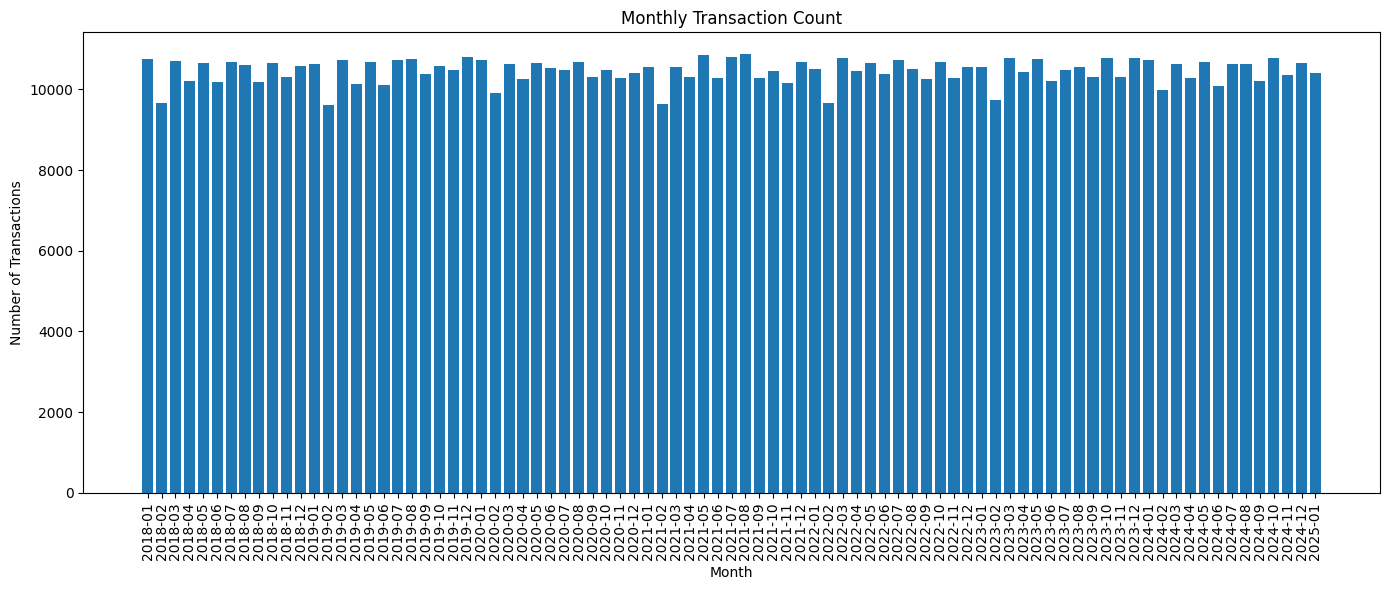

In [18]:
plt.figure(figsize=(14,6))
plt.bar(monthly_sales["Month_Year"], monthly_sales["transaction_count"])
plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("data/output/monthly_transaction_count.png", dpi=300)
plt.show()

Sales Trend (Moving Average)

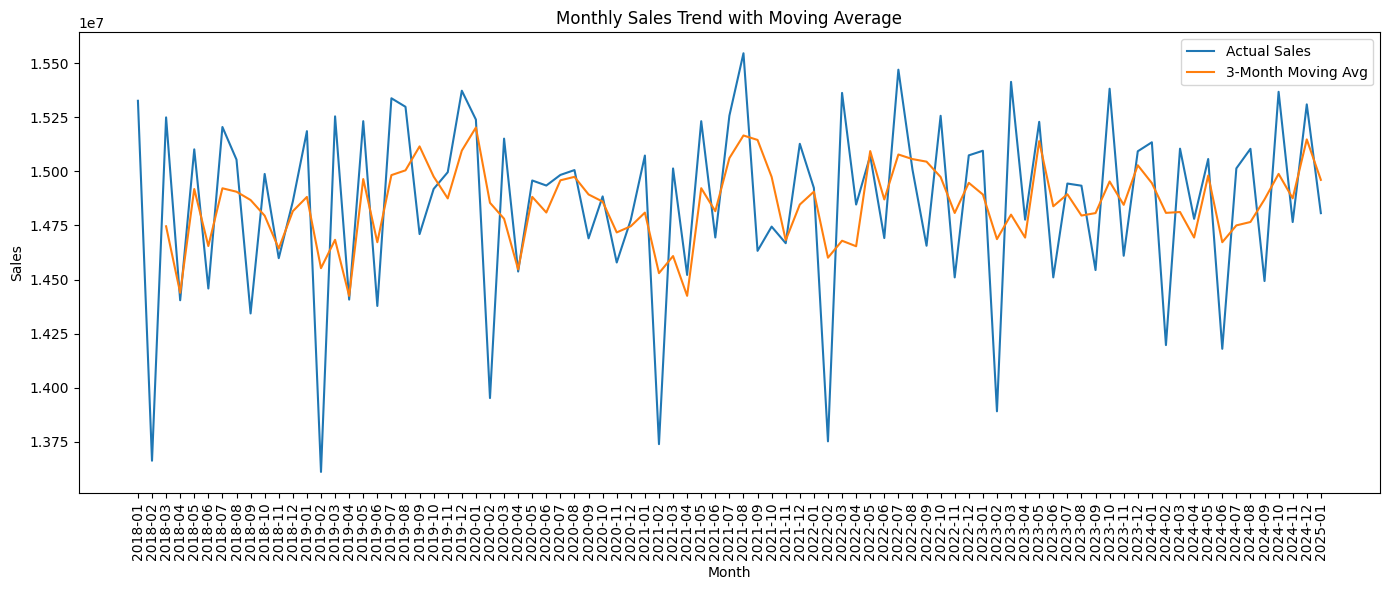

In [19]:
monthly_sales["rolling_avg"] = monthly_sales["total_sales"].rolling(window=3).mean()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales["Month_Year"], monthly_sales["total_sales"], label="Actual Sales")
plt.plot(monthly_sales["Month_Year"], monthly_sales["rolling_avg"], label="3-Month Moving Avg")
plt.title("Monthly Sales Trend with Moving Average")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("data/output/monthly_trend_moving_avg.png", dpi=300)
plt.show()

Prepare ML model dataset

In [20]:
model_df = df.copy()

features = [
    "Gender",
    "Age",
    "Marital_status",
    "State_names",
    "Segment",
    "Employees_status",
    "Payment_method",
    "Referral",
    "Year",
    "Month",
    "Quarter",
    "Hour"
]

target = "Amount_spent"

model_df = model_df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

print("Model dataset shape:", model_df.shape)

Model dataset shape: (832888, 13)


Train-test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 666310
Testing rows: 166578


Build ML pipeline

In [22]:
categorical_features = [
    "Gender",
    "Marital_status",
    "State_names",
    "Segment",
    "Employees_status",
    "Payment_method"
]

numeric_features = [
    "Age",
    "Referral",
    "Year",
    "Month",
    "Quarter",
    "Hour"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Model pipeline created")

Model pipeline created


Train model

In [23]:
pipeline.fit(X_train, y_train)

print("Model training completed")

Model training completed


Evaluate model

In [25]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Model Evaluation Results
MAE: 0.88
RMSE: 21.78
R2 Score: 0.9994


Prediction results table

In [26]:
results = pd.DataFrame({
    "Actual_Amount_Spent": y_test.values,
    "Predicted_Amount_Spent": y_pred
})

results.to_csv("data/output/model_predictions.csv", index=False)

results.head(20)

,Actual_Amount_Spent,Predicted_Amount_Spent
0,2083.16,2083.16
1,1401.27,1401.27
2,1453.75,1453.75
3,88.80,88.80
4,1802.33,1802.33
5,2679.12,2679.12
6,975.49,975.49
7,2600.69,2600.69
8,2997.21,2997.21
9,321.63,321.63


Graph 5 — Actual vs predicted

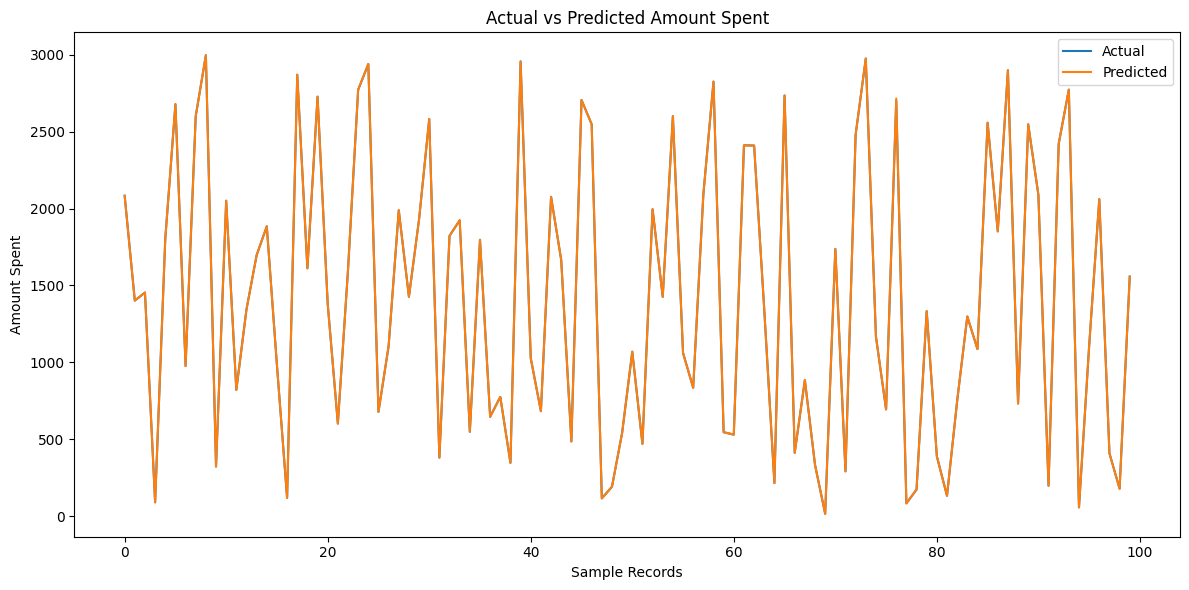

In [27]:
sample_results = results.head(100)

plt.figure(figsize=(12,6))
plt.plot(sample_results["Actual_Amount_Spent"].values, label="Actual")
plt.plot(sample_results["Predicted_Amount_Spent"].values, label="Predicted")
plt.title("Actual vs Predicted Amount Spent")
plt.xlabel("Sample Records")
plt.ylabel("Amount Spent")
plt.legend()
plt.tight_layout()
plt.savefig("data/output/actual_vs_predicted.png", dpi=300)
plt.show()

Scatter Plot (Actual vs Predicted)

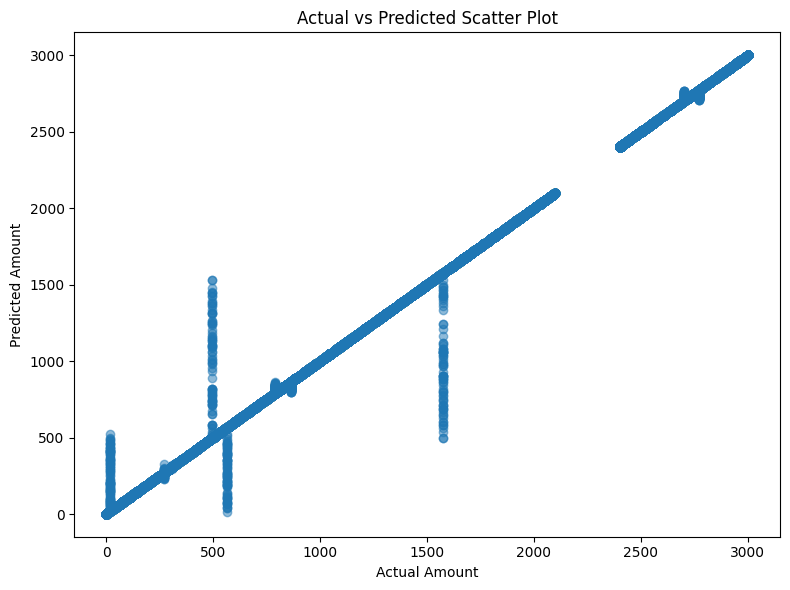

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Actual vs Predicted Scatter Plot")
plt.xlabel("Actual Amount")
plt.ylabel("Predicted Amount")
plt.tight_layout()
plt.savefig("data/output/scatter_actual_vs_predicted.png", dpi=300)
plt.show()

Residual Errors Distribution

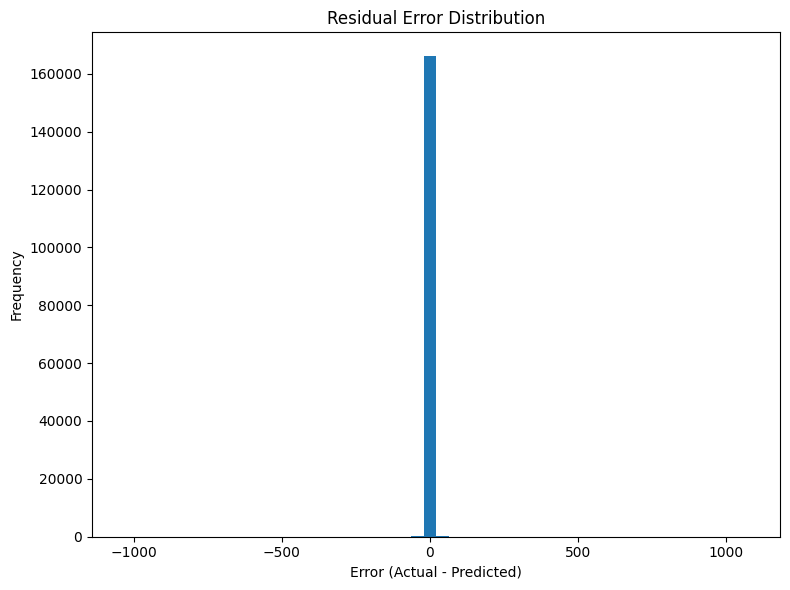

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50)
plt.title("Residual Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("data/output/residual_distribution.png", dpi=300)
plt.show()

Residual Plot

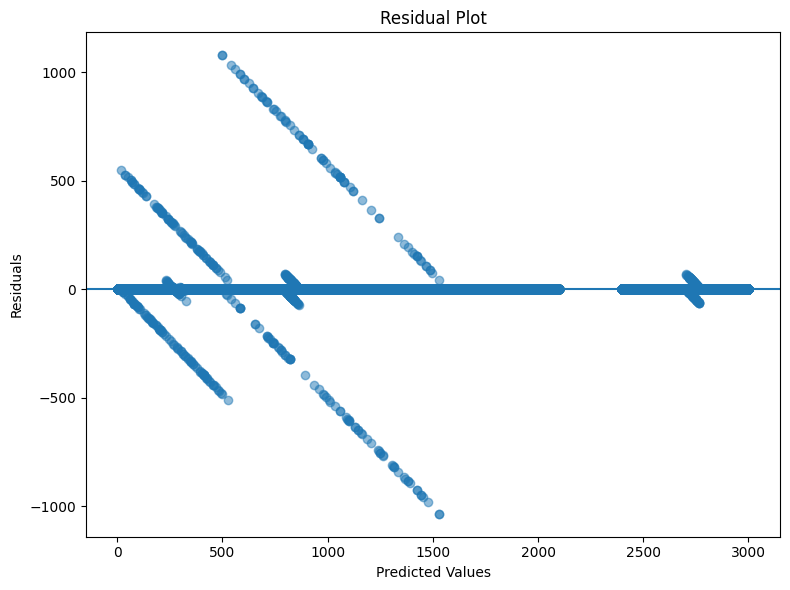

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("data/output/residual_plot.png", dpi=300)
plt.show()

In [ ]:
joblib.dump(pipeline, "models/amount_spent_prediction_model.pkl")

print("Model saved successfully")

Model saved successfully


Download all outputs as ZIP

In [31]:
!zip -r phase2_batch_processing_outputs.zip data models

from google.colab import files
files.download("phase2_batch_processing_outputs.zip")

  adding: data/ (stored 0%)
  adding: data/processed/ (stored 0%)
  adding: data/processed/cleaned_transactions.csv (deflated 85%)
  adding: data/raw/ (stored 0%)
  adding: data/output/ (stored 0%)
  adding: data/output/segment_sales.csv (deflated 28%)
  adding: data/output/residual_distribution.png (deflated 33%)
  adding: data/output/scatter_actual_vs_predicted.png (deflated 14%)
  adding: data/output/monthly_sales.csv (deflated 55%)
  adding: data/output/actual_vs_predicted.png (deflated 4%)
  adding: data/output/residual_plot.png (deflated 13%)
  adding: data/output/segment_sales.png (deflated 31%)
  adding: data/output/monthly_avg_sales.png (deflated 10%)
  adding: data/output/monthly_transaction_count.png (deflated 31%)
  adding: data/output/quarterly_sales.csv (deflated 51%)
  adding: data/output/monthly_trend_moving_avg.png (deflated 7%)
  adding: data/output/payment_method_sales.png (deflated 33%)
  adding: data/output/model_predictions.csv (deflated 77%)
  adding: data/output

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>